In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler,RobustScaler
from itertools import combinations

In [31]:

df = pd.read_csv('airfoil_self_noise.dat', sep='\s+', header=None)

df.columns = [
    'Frequency', 
    'Angle_of_Attack', 
    'Chord_Length', 
    'Stream_Velocity', 
    'Displacement_Thickness', 
    'Y'
]
df['Frequency'] = np.log10(df['Frequency'])

### 2. Trực quan hóa dữ liệu

,Y
count,1503.000000
mean,124.835943
std,6.898657
min,103.380000
25%,120.191000
50%,125.721000
75%,129.995500
max,140.987000


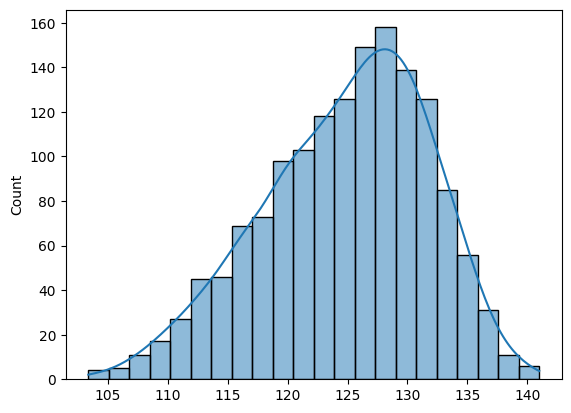

In [32]:
sns.histplot(df.Y.values, kde=True)
pd.DataFrame(data=df.Y.values, columns=["Y"]).describe()

### 3. Chuẩn bị dữ liệu huấn luyện và kiểm tra

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
X = df.drop(["Y"], axis=1) 
y = df.get(["Y"]) 
     
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    random_state=45   
)
y_test = y_test.values 
y_train = y_train.values 



In [34]:

scaler = StandardScaler()
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### 4. Xây dựng mô hình

In [35]:
model1 = linear_model.LinearRegression()
model1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 5. Đánh giá

In [36]:
def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true).astype(float) / y_true
    return np.mean(errors)*100

In [37]:
y_pred_test = model1.predict(X_test)
print ('RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred_test))))
print ('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred_test)))



RMSE: 5.26
Mean relative errors: 3.3%


### 6. Trực quan hóa và đánh giá kết quả

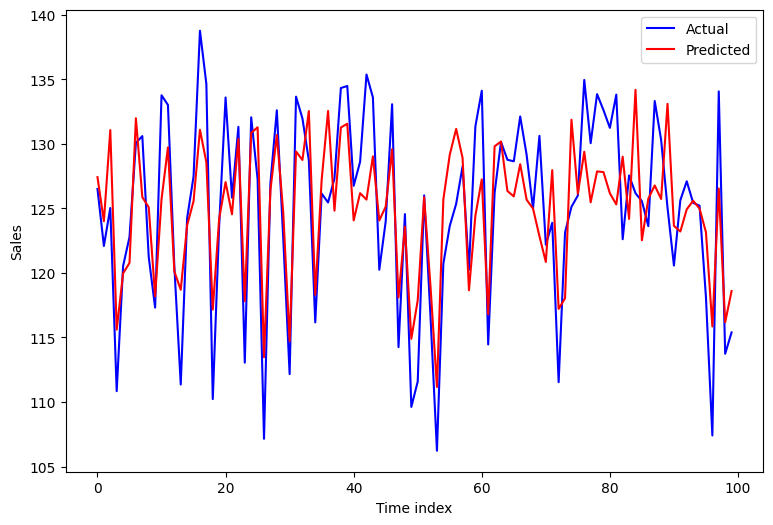

In [38]:
y_pred_train = model1.predict(X_train)
plt.figure(figsize=(9,6))
plt.plot(y_train[:100], color='blue', label='Actual')
plt.plot(y_pred_train[:100], color='red', label='Predicted')
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [39]:
def get_interactions(X):
    n_samples, n_features = X.shape
    one = np.ones((n_samples, 1))
    interactions = [one]
    interactions.append(X)
    interactions.append(X**2)
    interactions.append(X**3)
    interactions.append(X**4)
    
    for i, j in combinations(range(n_features), 2):
        new_col = X[:, i] * X[:, j]
        interactions.append(new_col)
    for i, j in combinations(range(n_features), 2):
        new_col = (X[:, i]**2) * X[:, j]
        interactions.append(new_col)
    for i, j in combinations(range(n_features), 2):
        new_col = (X[:, i]) * (X[:, j]**2)
        interactions.append(new_col)
    for i, j in combinations(range(n_features), 2):
        new_col = (X[:, i]**3) * X[:, j]
        interactions.append(new_col)
    for i, j in combinations(range(n_features), 2):
        new_col = (X[:, i]) * (X[:, j]**3)
        interactions.append(new_col)
    for i, j in combinations(range(n_features), 2):
        new_col = (X[:, i]**4) * X[:, j]
        interactions.append(new_col)
    for i, j in combinations(range(n_features), 2):
        new_col = (X[:, i]) * (X[:, j]**4)
        interactions.append(new_col)
    return np.column_stack(interactions)



In [40]:
X_features1 = get_interactions(X_train)
X_features2 = get_interactions(X_test)



In [41]:
model3 = linear_model.LinearRegression()
model3.fit(X_features1, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred_test = model3.predict(X_features2)
print ('RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_test, y_pred_test))))
print ('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred_test)))
y_pred_train = model3.predict(X_features1)
print ('Train RMSE: {:.2f}'.format(np.sqrt(mean_squared_error(y_train, y_pred_train))))
print ('Train Mean relative errors: {:.1f}%'.format(relative_error(y_train, y_pred_train)))

RMSE: 2.46
Mean relative errors: 1.4%
Train RMSE: 2.17
Train Mean relative errors: 1.3%


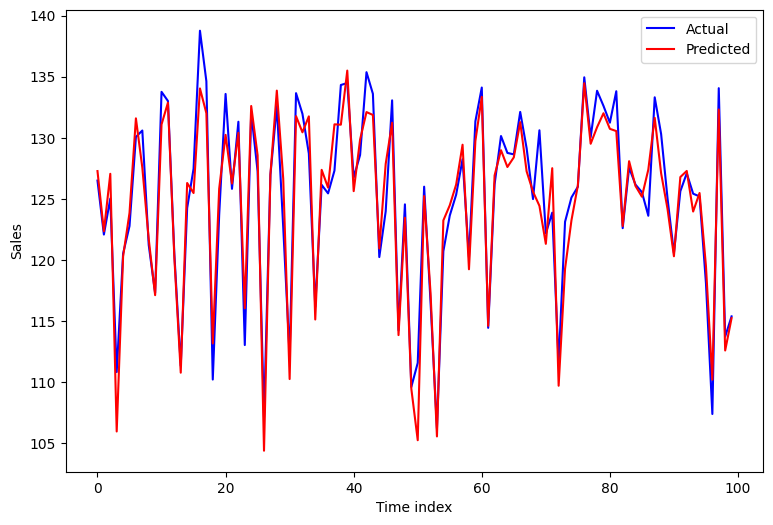

In [43]:
y_pred_train = model3.predict(X_features1)
plt.figure(figsize=(9,6))
plt.plot(y_train[:100], color='blue', label='Actual')
plt.plot(y_pred_train[:100], color='red', label='Predicted')
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
plt.show()